In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Parte 1: Geração aleatória do Grafo

[1, 7, 9]


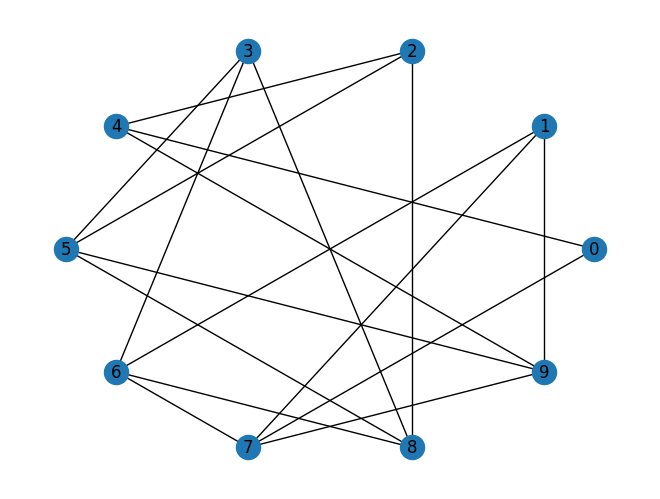

In [ ]:
# Gerando e exibindo um grafo aleatório
# Y = nx.DiGraph() # Inicializa o grafo
Y = nx.random_graphs.gnp_random_graph(n=10, p=0.5) # Gera um grafo aleatório com n vértices e p chance de ser conectado a outro
Y.nodes.data('pos')
# Y = nx.cycle_graph(10)
for n in Y.nodes():
  Y.nodes[n]['pos'] = n

nx.draw(Y, pos = nx.circular_layout(Y), with_labels = True) # Exibe o grafo aleatório no layout circular

cliques = list(nx.find_cliques(Y))
cliques = sorted(cliques, key=len, reverse=True) # Ordena os cliques dos maiores pro menores
print(cliques[0])


# Parte 2: Colorindo o Grafo

Indíce: 6  <-- Cor: 1
Indíce: 7  <-- Cor: 1
Indíce: 9  <-- Cor: 1
Indíce: 0  <-- Cor: 2
Indíce: 6   <-- Cor: 2
Indíce: 9   <-- Cor: 2
Indíce: 4  <-- Cor: 0
Indíce: 5  <-- Cor: 0
Indíce: 3  <-- Cor: 0
Indíce: 8  <-- Cor: 0
Indíce: 2  <-- Cor: 1
Indíce: 3   <-- Cor: 1
Indíce: 8   <-- Cor: 1
Indíce: 2   <-- Cor: 2
Indíce: 3   <-- Cor: 0
Indíce: 3   <-- Cor: 2
Indíce: 6   <-- Cor: 0
Indíce: 1   <-- Cor: 1
Indíce: 1   <-- Cor: 0
Cliques:  [[1, 7, 9], [1, 7, 6], [5, 8, 2], [5, 8, 3], [6, 8, 3], [0, 4], [0, 7], [4, 9], [4, 2], [5, 9]]
Cores:    [2, 0, 2, 2, 0, 0, 0, 1, 1, 2]


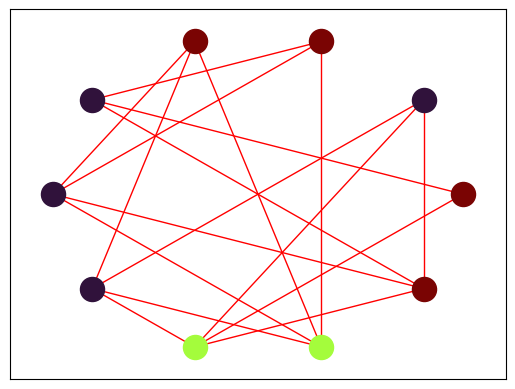

In [ ]:
qtdCores = 3 # Quantas cores estarão disponiveis pra colorir o grafo

colors = plt.cm.turbo(np.linspace(0,1,qtdCores)) # Faz uma lista com as cores baseado no "Turbo"
#print(plt.cm.cmaps_listed.keys()) #  Mostra o "ramo" de cores que podem ser setadas

cor = 0 # Variável que vai andar na lista sorteando as cores

# Lista que irá guardar o indíce da cor designada ao respectivo nó
pintados =  [-1 for i in range(len(Y.nodes()))]

isPossible = True

# Checa os cliques e define se há uma solução possível
cliques = list(nx.find_cliques(Y))
cliques = sorted(cliques, key=len, reverse=True) #  Ordena os clicks em ordem dos maiores pro menores
if(len(cliques[0]) > qtdCores):        # Relação do número de elementos do maior clique com as cores disponíveis
  print("Não há cores suficientes. São necessário pelo menos", len(cliques[0]), "cores.")
  isPossible = False

# Se há uma solução bora encontrar!
if(isPossible):
  for i in range(len(cliques)):         # Looping que servirá como índice na lista de cliques (o range determina quantos cliques há)
    for no_atual in cliques[i]:         # Looping que percorrerá todos os cliques do grafo
      if(pintados[no_atual] == -1):     # Se o nó atual ainda não foi pintado, atribui a primeira cor a ele (0)
          pintados[no_atual] = 0

      while(cor == pintados[no_atual]): # Localiza uma cor não conflitante com o nó atual
            cor = (cor+1) % qtdCores    # Passa para próxima cor

      # Até então foi localizada uma cor não conflitante com o nó_atual, agora devemos partir para os vizinhos
      for j in Y.neighbors(no_atual):   # Looping 2 que percorrerá todos os vizinhos do nó_atual
        if(pintados[j] == -1):          # Se o vizinho não está pintado ainda, atribui a cor não conflitante a ele
          pintados[j] = cor
          print("Indíce:", j, " <-- Cor:", cor)

        if(pintados[j] != -1 and pintados[j] != pintados[no_atual]):  #  Se o vizinho já está pintado e não tem conflito apenas continua
          continue

        for k in Y.neighbors(j):        # Loop 3 que ira ver se não há conflito com nenhum vizinho do vizinho
          while(cor == pintados[k] or cor == pintados[no_atual] or cor == pintados[j]):    # Não para enquanto não encontrar uma cor que não conflita com ninguém
            cor = (cor+1) % qtdCores

        pintados[j] = cor #  Atribui a cor não conflitante ao nó
        print("Indíce:", j, "  <-- Cor:", cor)



  # Print do grafo
  for i in Y.nodes:   # Loop do print dos nós colorindo-os baseado na lista pintados
    nx.draw_networkx_nodes(Y, nodelist=[i], node_color = colors[pintados[i]], pos = nx.circular_layout(Y))
  # Print das linhas
  nx.draw_networkx_edges(Y, edge_color="# FF0000", pos = nx.circular_layout(Y));

  print("Cliques: ", cliques)
  print("Cores:   ", pintados)